### Zhong_Yuan_DSCI552_homework2

## a

In [9]:
%pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd

df = pd.read_excel( "CCPP/Folds5x2_pp.xlsx", sheet_name = 0)

display(df.head())
df.shape
df.info()
df.isna().sum()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

## b

i. First four columns are predictors and the fifth is the target, and each row represents an observation.

ii. The pairwise scatterplots show strong negative associations between PE and both AT and V, with correlations of approximately −0.948 and −0.870, respectively. PE has positive associations with AP and RH, with correlations of approximately 0.518 and 0.390. The predictors are also related: AT and V have a strong positive correlation of approximately 0.844, while AT is negatively correlated with AP and RH. These relationships suggest that individual regression coefficients may change when other predictors are included in the model.

In [16]:
print("number of rows:", df.shape[0])
print("number of columns:", df.shape[1])

number of rows: 9568
number of columns: 5


Help on function pairplot in module seaborn.axisgrid:

pairplot(
    data,
    *,
    hue=None,
    hue_order=None,
    palette=None,
    vars=None,
    x_vars=None,
    y_vars=None,
    kind='scatter',
    diag_kind='auto',
    markers=None,
    height=2.5,
    aspect=1,
    corner=False,
    dropna=False,
    plot_kws=None,
    diag_kws=None,
    grid_kws=None,
    size=None
)
    Plot pairwise relationships in a dataset.

    By default, this function will create a grid of Axes such that each numeric
    variable in ``data`` will by shared across the y-axes across a single row and
    the x-axes across a single column. The diagonal plots are treated
    differently: a univariate distribution plot is drawn to show the marginal
    distribution of the data in each column.

    It is also possible to show a subset of variables or plot different
    variables on the rows and columns.

    This is a high-level interface for :class:`PairGrid` that is intended to
    make it easy to draw a

Text(0.5, 1.02, 'Scatterplots of Features by PE')

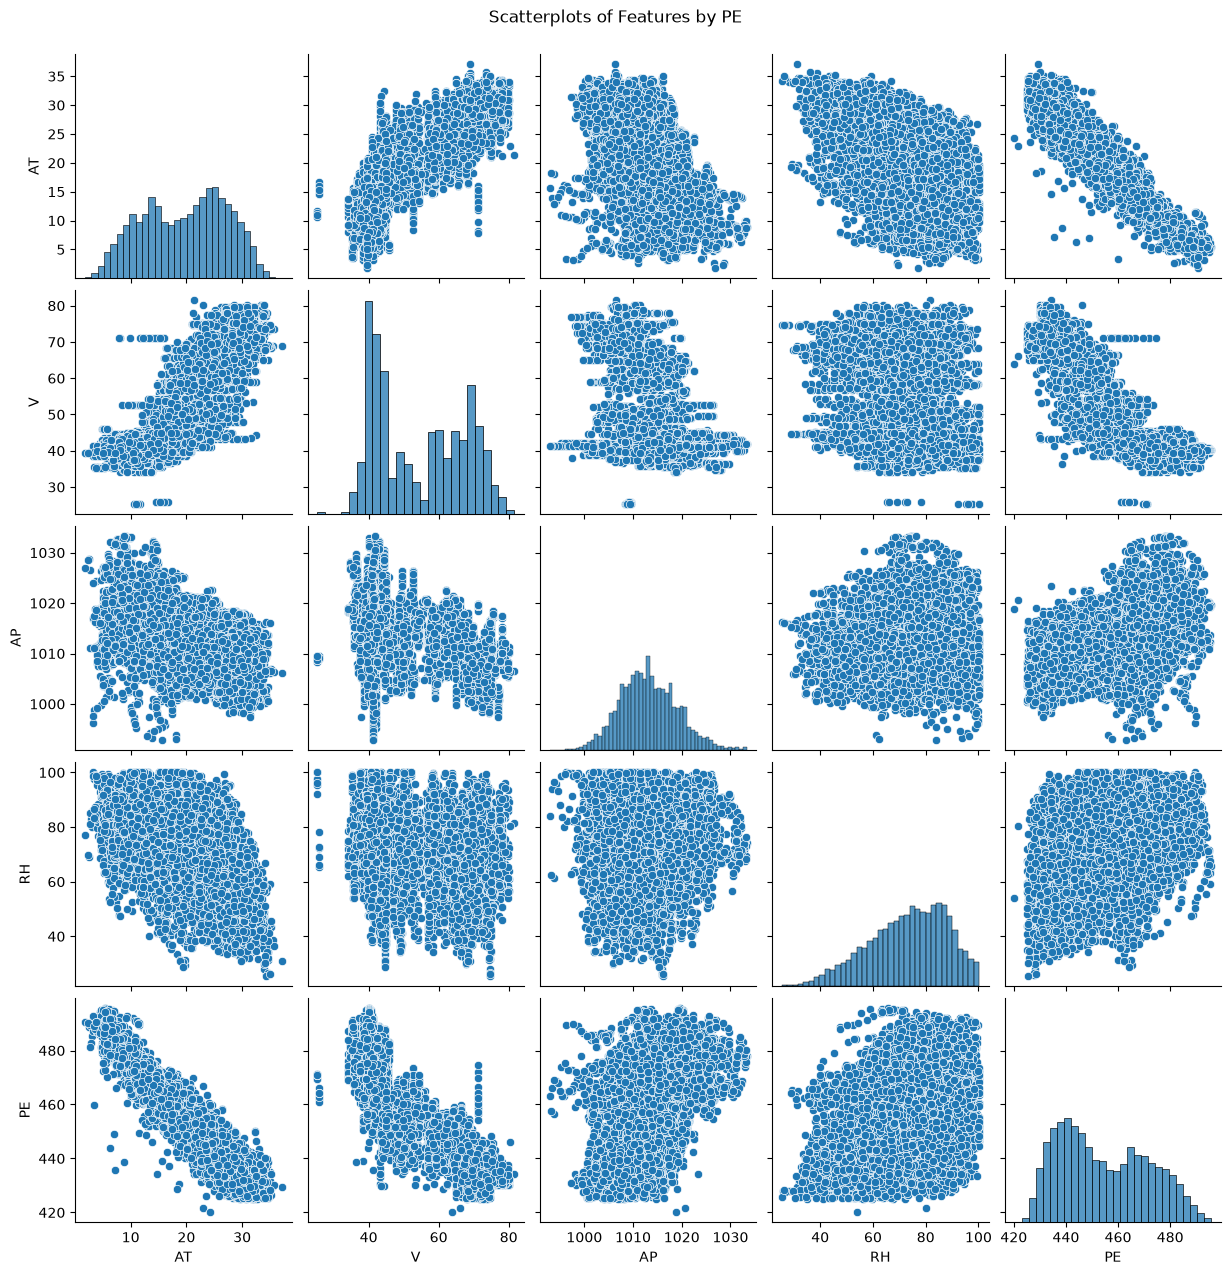

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
help(sns.pairplot)
features = ["AT", "V", "AP", "RH"]

g = sns.pairplot(
    data=df,
    diag_kind="hist"
)

g.fig.suptitle("Scatterplots of Features by PE", y=1.02)

In [50]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary.round(3)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


In [51]:
df.corr()["PE"].drop("PE").round(3)

AT   -0.948
V    -0.870
AP    0.518
RH    0.390
Name: PE, dtype: float64

## c

All four predictors have statistically significant associations with PE in their respective simple linear regressions, with all slope p-values below 0.001. AT and V have negative coefficients of −2.171 and −1.168, while AP and RH have positive coefficients of 1.4899 and 0.4557. AT provides the strongest fit R^2=0.899, followed by V (0.757), AP (0.269), and RH (0.152). Using an absolute externally studentized residual threshold of 3 identifies 42, 33, 30, and 2 potential outliers in the AT, V, AP, and RH models, respectively. These observations were retained because large residuals alone do not establish measurement errors and may reflect limitations of the single-predictor models.

In [27]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 7.7 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/11.3 MB 5.9 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 5.0 MB/s eta 0:00:02
   ------------ --------------------------- 3.4/11.3 MB 4.5 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 4.0 MB/s eta 0:00:02
   ---------------- ----------------------- 4.7/11.3 MB 3.9 MB/s eta 0:00:02
   ------------------ --------------------- 5.2/11.3 MB 3.8 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.3 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.3 MB 3.5 MB/s eta 0:00:02
   ------------------------- -------------- 7.1/11.3 MB 3.4 MB/s eta 0:00:02
   ------------------------- -------------- 7.3/11.3 MB 3.4 MB/s eta 0:00:02
   ---------------------------- ----------- 8.1/11.3 MB 3.4 MB/s eta 0:00:01
   ---


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
import statsmodels.api as sm

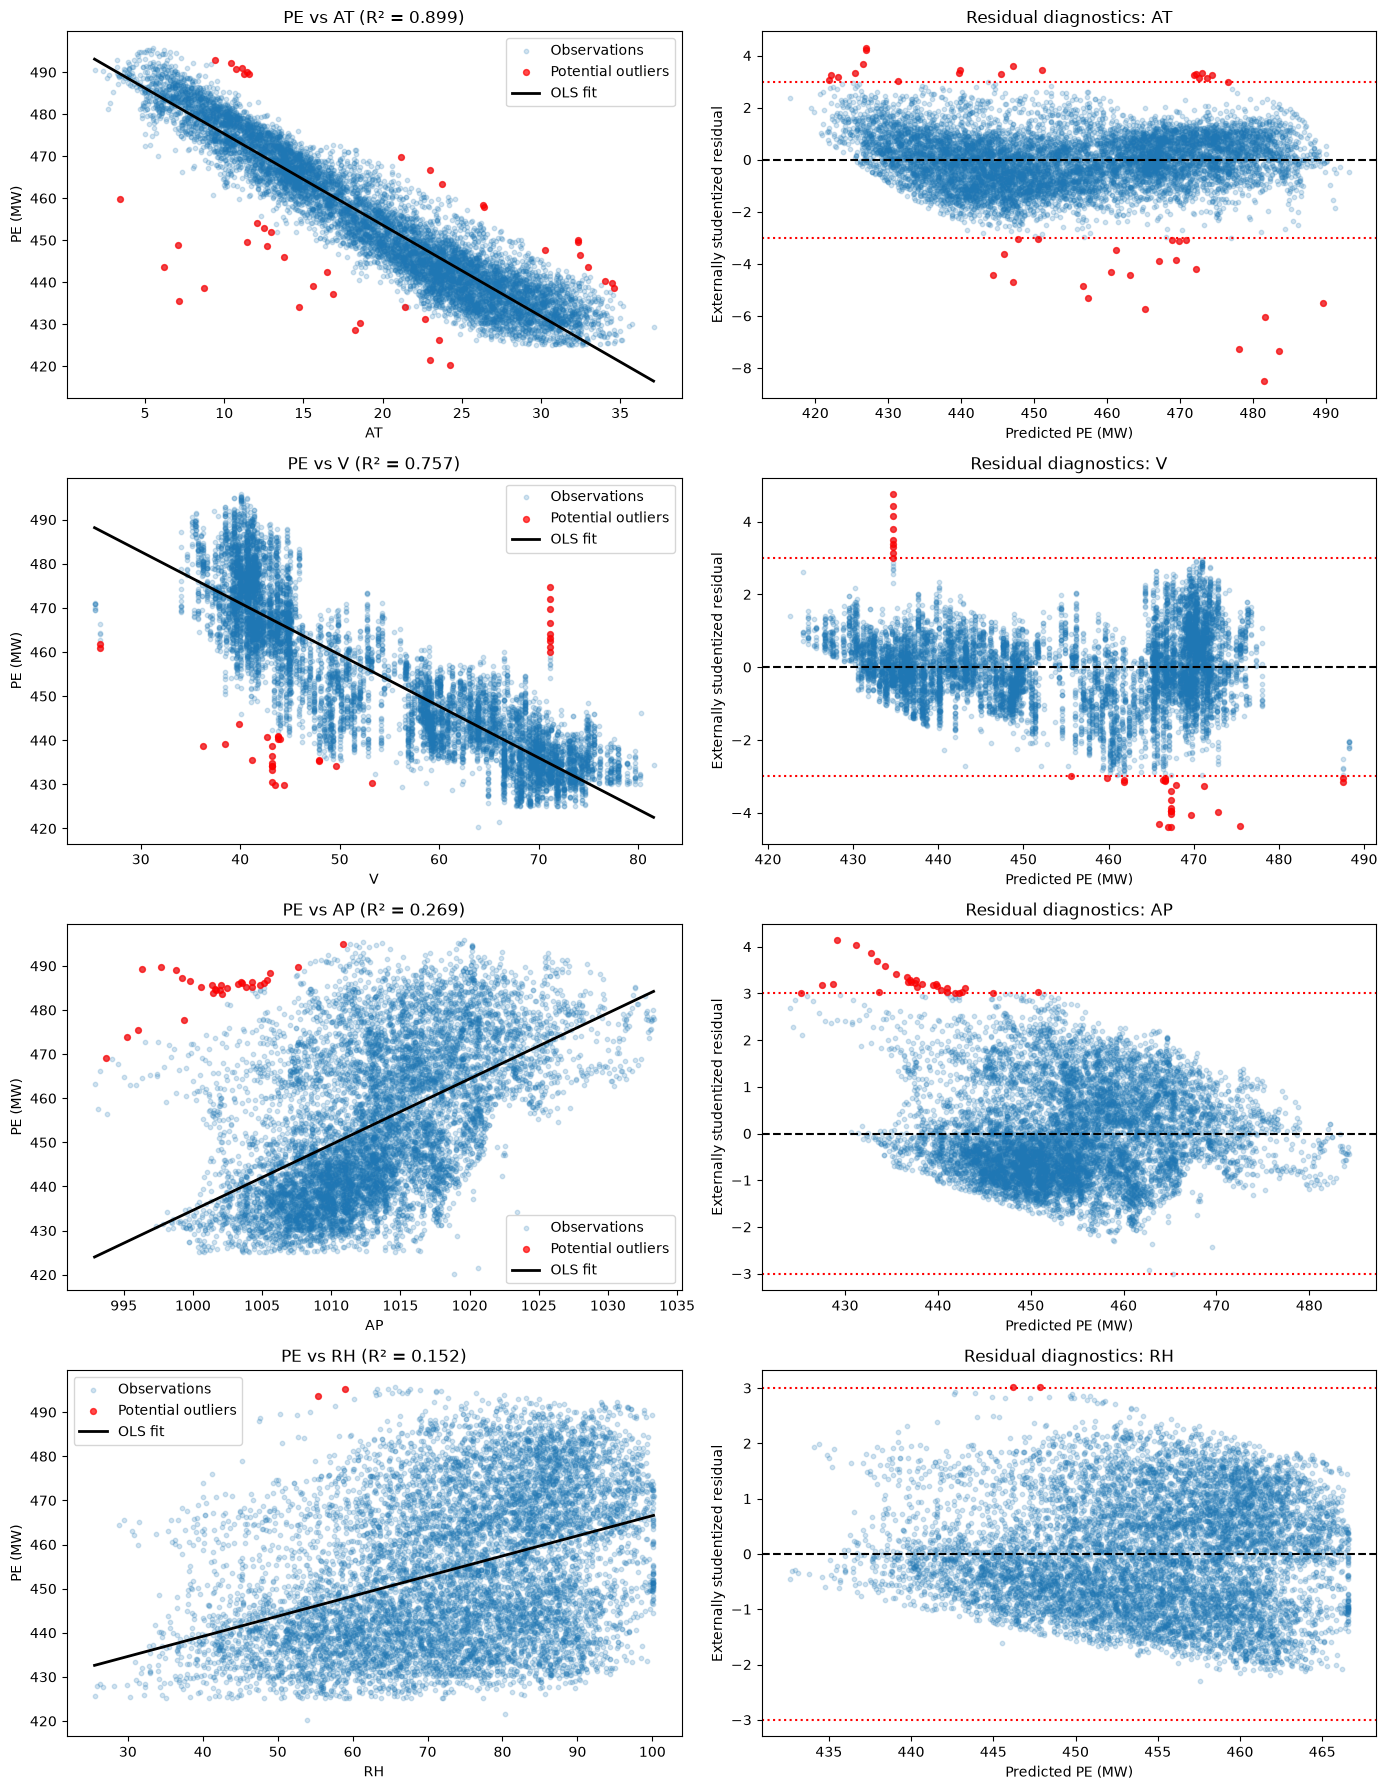

,Intercept,Slope,Slope SE,t statistic,p-value,R-squared,CI lower,CI upper,Potential outliers
Predictor,,,,,,,,,
AT,497.034120,-2.171320,0.007443,-291.715195,0.0,0.898948,-2.185910,-2.156730,42
V,517.801526,-1.168135,0.006776,-172.401540,0.0,0.756518,-1.181417,-1.154853,33
AP,-1055.260989,1.489872,0.025126,59.296232,0.0,0.268769,1.440620,1.539124,30
RH,420.961766,0.455650,0.011006,41.398730,0.0,0.151939,0.434075,0.477225,2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

predictors = ["AT", "V", "AP", "RH"]
y = df["PE"]

models = {}
results = []
potential_outliers = {}

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for i, variable in enumerate(predictors):

    X = sm.add_constant(df[[variable]])
    model = sm.OLS(y, X).fit()
    models[variable] = model

    influence = model.get_influence()
    r = influence.resid_studentized_internal

    studentized_residuals = r * np.sqrt(
        (model.df_resid - 1) / (model.df_resid - r**2)
    )

    outlier_mask = np.abs(studentized_residuals) > 3

    flagged = df.loc[outlier_mask, [variable, "PE"]].copy()
    flagged["Studentized residual"] = (
        studentized_residuals[outlier_mask]
    )
    potential_outliers[variable] = flagged

    ci = model.conf_int().loc[variable]

    results.append({
        "Predictor": variable,
        "Intercept": model.params["const"],
        "Slope": model.params[variable],
        "Slope SE": model.bse[variable],
        "t statistic": model.tvalues[variable],
        "p-value": model.pvalues[variable],
        "R-squared": model.rsquared,
        "CI lower": ci.iloc[0],
        "CI upper": ci.iloc[1],
        "Potential outliers": int(outlier_mask.sum())
    })

    ax = axes[i, 0]

    ax.scatter(
        df[variable], y,
        s=10, alpha=0.2, label="Observations"
    )
    ax.scatter(
        df.loc[outlier_mask, variable],
        y.loc[outlier_mask],
        s=18, color="red", alpha=0.7,
        label="Potential outliers"
    )

    x_line = np.linspace(
        df[variable].min(), df[variable].max(), 200
    )
    y_line = (
        model.params["const"]
        + model.params[variable] * x_line
    )

    ax.plot(
        x_line, y_line,
        color="black", linewidth=2, label="OLS fit"
    )
    ax.set_xlabel(variable)
    ax.set_ylabel("PE (MW)")
    ax.set_title(
        f"PE vs {variable} "
        f"(R² = {model.rsquared:.3f})"
    )
    ax.legend()

    ax = axes[i, 1]

    ax.scatter(
        model.fittedvalues, studentized_residuals,
        s=10, alpha=0.2
    )
    ax.scatter(
        model.fittedvalues[outlier_mask],
        studentized_residuals[outlier_mask],
        s=18, color="red", alpha=0.7
    )

    ax.axhline(0, color="black", linestyle="--")
    ax.axhline(3, color="red", linestyle=":")
    ax.axhline(-3, color="red", linestyle=":")

    ax.set_xlabel("Predicted PE (MW)")
    ax.set_ylabel("Externally studentized residual")
    ax.set_title(f"Residual diagnostics: {variable}")

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).set_index("Predictor")
display(results_df)

## d

All four predictors have p-values below 0.05, so the null hypothesis is rejected for each predictor. Holding the other predictors constant, AT, V, and RH are negatively associated with PE, whereas AP is positively associated with PE. The model achieves R^2=0.929, explaining approximately 92.9% of the variation in PE.

In [43]:
X = df[["AT", "V", "AP", "RH"]]
y = df[["PE"]]

X = sm.add_constant(X)
multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:24:02   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

## e

The coefficient comparison plot shows that AT remains negative with a relatively small change, from −2.1713 to −1.9775. The coefficients of V and AP decrease substantially in magnitude, from −1.1681 to −0.2339 and from 1.4899 to 0.0621, respectively. RH changes sign, from 0.4557 to −0.1581. These differences arise because simple regressions describe marginal associations, whereas multiple regression coefficients describe associations after controlling for the other predictors. Correlations among the predictors therefore affect the estimated coefficients.

,Simple regression,Multiple regression
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


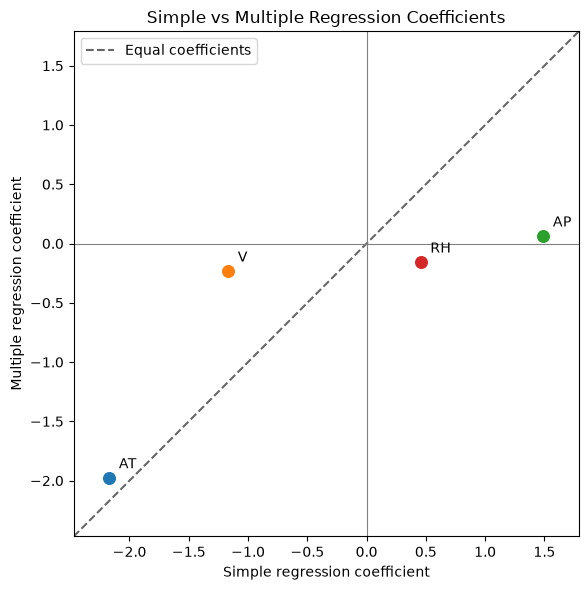

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

predictors = ["AT", "V", "AP", "RH"]

coef_comparison = pd.DataFrame({
    "Simple regression": [
        models[var].params[var] for var in predictors
    ],
    "Multiple regression": [
        multiple_model.params[var] for var in predictors
    ]
}, index=predictors)

display(coef_comparison.round(4))

fig, ax = plt.subplots(figsize=(7, 6))

for var in predictors:
    x = coef_comparison.loc[var, "Simple regression"]
    y = coef_comparison.loc[var, "Multiple regression"]

    ax.scatter(x, y, s=70)
    ax.annotate(
        var, (x, y),
        xytext=(7, 7), textcoords="offset points"
    )

lower = coef_comparison.to_numpy().min() - 0.3
upper = coef_comparison.to_numpy().max() + 0.3

ax.plot(
    [lower, upper], [lower, upper],
    "k--", alpha=0.6, label="Equal coefficients"
)

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Simple regression coefficient")
ax.set_ylabel("Multiple regression coefficient")
ax.set_title("Simple vs Multiple Regression Coefficients")
ax.legend()

plt.tight_layout()
plt.show()

## f

Cubic regression models provide evidence of nonlinear associations between PE and all four predictors. Joint F-tests of H_0: = beta_3=0 produce p-values below 0.05 for every predictor. In the models using uncentered powers, both quadratic and cubic terms are significant for AT, AP, and RH; for V, the cubic term is significant although the quadratic term is not. The cubic models achieve R^2 values of 0.9119, 0.7750, 0.2975, and 0.1537 for AT, V, AP, and RH, respectively. The improvement for RH is very small despite being statistically significant.

C:\Users\zhong\AppData\Local\Temp\ipykernel_48336\3551022515.py:24: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  cubic_model = sm.OLS(y, X_cubic).fit()


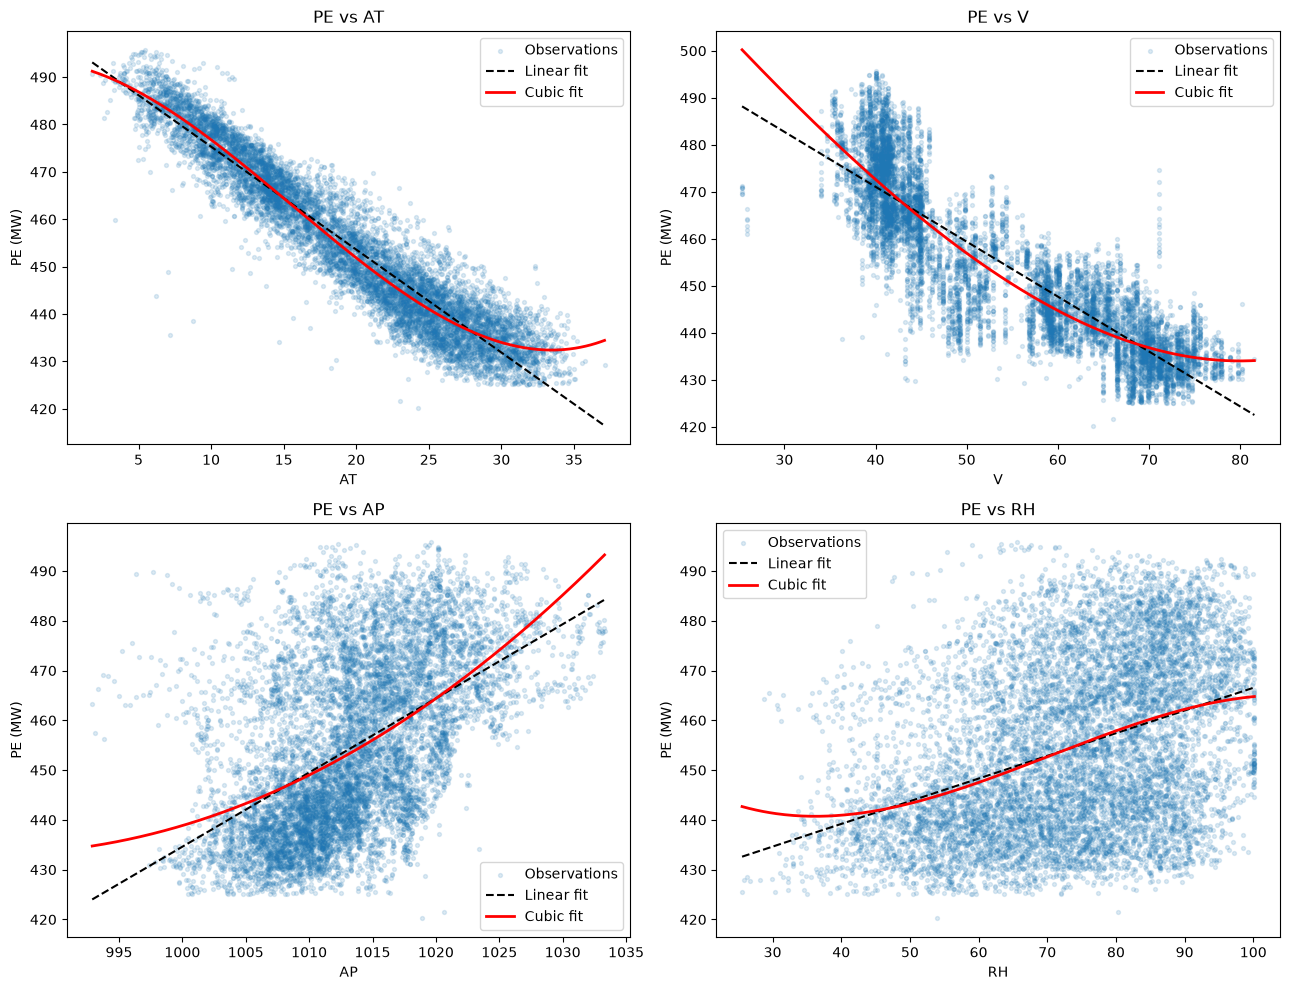

,p-value X2,p-value X3,Nonlinear F,Nonlinear p-value,Linear R2,Cubic R2
Predictor,,,,,,
AT,8.833045e-73,3.652185e-110,701.967278,3.478379e-285,0.898948,0.911883
V,7.684969e-01,1.373489e-02,393.314147,7.040303e-165,0.756518,0.775022
AP,3.666705e-17,8.264146e-18,906.321778,0.000000e+00,0.268769,0.274863
RH,9.395430e-06,1.440279e-05,10.188863,3.799622e-05,0.151939,0.153743


In [45]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

predictors = ["AT", "V", "AP", "RH"]
y = df["PE"]

polynomial_models = {}
results = []

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for variable, ax in zip(predictors, axes.flat):
    x = df[variable]

    X_cubic = pd.DataFrame({
        "X": x,
        "X2": x**2,
        "X3": x**3
    })
    X_cubic = sm.add_constant(X_cubic)

    cubic_model = sm.OLS(y, X_cubic).fit()
    polynomial_models[variable] = cubic_model

    X_linear = sm.add_constant(df[[variable]])
    linear_model = sm.OLS(y, X_linear).fit()

    nonlinear_test = cubic_model.f_test("X2 = 0, X3 = 0")

    results.append({
        "Predictor": variable,
        "p-value X2": cubic_model.pvalues["X2"],
        "p-value X3": cubic_model.pvalues["X3"],
        "Nonlinear F": float(np.asarray(
            nonlinear_test.fvalue
        ).item()),
        "Nonlinear p-value": float(np.asarray(
            nonlinear_test.pvalue
        ).item()),
        "Linear R2": linear_model.rsquared,
        "Cubic R2": cubic_model.rsquared
    })

    x_grid = np.linspace(x.min(), x.max(), 300)

    grid_cubic = pd.DataFrame({
        "const": np.ones(len(x_grid)),
        "X": x_grid,
        "X2": x_grid**2,
        "X3": x_grid**3
    })

    cubic_predictions = cubic_model.predict(grid_cubic)
    linear_predictions = (
        linear_model.params["const"]
        + linear_model.params[variable] * x_grid
    )

    ax.scatter(x, y, s=8, alpha=0.15, label="Observations")
    ax.plot(
        x_grid, linear_predictions,
        color="black", linestyle="--",
        label="Linear fit"
    )
    ax.plot(
        x_grid, cubic_predictions,
        color="red", linewidth=2,
        label="Cubic fit"
    )

    ax.set_xlabel(variable)
    ax.set_ylabel("PE (MW)")
    ax.set_title(f"PE vs {variable}")
    ax.legend()

plt.tight_layout()
plt.show()

nonlinear_results = pd.DataFrame(results).set_index("Predictor")
display(nonlinear_results)

## g

In the model containing all four main effects and all six pairwise interactions, AT×V, AT×RH, V×AP, and AP×RH are statistically significant at the unadjusted 5% level. Their p-values are approximately 3.33 * 10^-117, 1.22 * 10^-10, 2.88 * 10^-7, and 0.0336, respectively. AT×AP and V×RH are not significant, with p-values of 0.4521 and 0.0862. These results suggest that some predictor–response associations depend on the values of other predictors. The interaction model achieves R2 = 0.9363

In [46]:
import pandas as pd
import statsmodels.formula.api as smf

interaction_model = smf.ols(
    formula="PE ~ (AT + V + AP + RH)**2",
    data=df
).fit()

print(interaction_model.summary())

interaction_terms = [
    "AT:V", "AT:AP", "AT:RH",
    "V:AP", "V:RH", "AP:RH"
]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params.loc[interaction_terms],
    "p-value": interaction_model.pvalues.loc[interaction_terms]
})

interaction_results["Significant at 0.05"] = (
    interaction_results["p-value"] < 0.05
)

display(interaction_results)

print(f"R-squared: {interaction_model.rsquared:.4f}")
print(f"Adjusted R-squared: {interaction_model.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:44:11   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

,Coefficient,p-value,Significant at 0.05
AT:V,0.020971,3.333358e-117,True
AT:AP,0.001759,4.520509e-01,False
AT:RH,-0.005230,1.216944e-10,True
V:AP,0.006812,2.877026e-07,True
V:RH,0.000839,8.619366e-02,False
AP:RH,-0.001612,3.360557e-02,True


R-squared: 0.9363
Adjusted R-squared: 0.9362


## h

The data were randomly split into 70% training and 30% test sets using random_state=42. A baseline linear model was compared with an expanded model containing all main effects, squared terms, and pairwise interactions. Predictors were centered using training-set means, and backward elimination based on training-set p-values was performed while preserving model hierarchy. The terms V×RH, V², and V×AP were removed. The selected model reduced test MSE from 21.2399 to 18.6600, indicating improved predictive performance on this split. Its performance was nearly identical to that of the full quadratic model, despite using fewer terms.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

features = ["AT", "V", "AP", "RH"]

X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df["PE"],
    test_size=0.30,
    random_state=42
)

train_mean = X_train.mean()
Z_train = X_train - train_mean
Z_test = X_test - train_mean

def fit_ols(train_features):
    return sm.OLS(
        y_train,
        sm.add_constant(train_features, has_constant="add")
    ).fit()

def evaluate_ols(model, train_features, test_features):
    train_pred = model.predict(
        sm.add_constant(train_features, has_constant="add")
    )
    test_pred = model.predict(
        sm.add_constant(test_features, has_constant="add")
    )

    return {
        "Train MSE": mean_squared_error(y_train, train_pred),
        "Test MSE": mean_squared_error(y_test, test_pred)
    }

linear_model_h = fit_ols(Z_train)

def make_quadratic_features(Z):
    result = Z.copy()

    for variable in features:
        result[f"{variable}2"] = Z[variable] ** 2

    for a, b in combinations(features, 2):
        result[f"{a}:{b}"] = Z[a] * Z[b]

    return result

Q_train = make_quadratic_features(Z_train)
Q_test = make_quadratic_features(Z_test)

full_model_h = fit_ols(Q_train)

parents = {
    f"{variable}2": {variable}
    for variable in features
}

for a, b in combinations(features, 2):
    parents[f"{a}:{b}"] = {a, b}

selected_terms = list(Q_train.columns)
removed_terms = []

while True:
    current_model = fit_ols(Q_train[selected_terms])

    protected = set()

    for term in selected_terms:
        if term in parents:
            protected.update(parents[term])

    candidates = [
        term for term in selected_terms
        if term not in protected
    ]

    if not candidates:
        break

    candidate_pvalues = current_model.pvalues.loc[candidates]
    worst_term = candidate_pvalues.idxmax()
    worst_pvalue = candidate_pvalues.loc[worst_term]

    if worst_pvalue <= 0.05:
        break

    removed_terms.append((worst_term, worst_pvalue))
    selected_terms.remove(worst_term)

selected_model_h = fit_ols(Q_train[selected_terms])

regression_results = pd.DataFrame.from_dict({
    "Linear": evaluate_ols(
        linear_model_h, Z_train, Z_test
    ),
    "Full quadratic": evaluate_ols(
        full_model_h, Q_train, Q_test
    ),
    "Selected quadratic": evaluate_ols(
        selected_model_h,
        Q_train[selected_terms],
        Q_test[selected_terms]
    )
}, orient="index")

print("Removed terms:", removed_terms)
print("Retained terms:", selected_terms)
display(regression_results.round(4))

Removed terms: [('V:RH', np.float64(0.867382375873549)), ('V2', np.float64(0.6077327700555947)), ('V:AP', np.float64(0.35782550384283884))]
Retained terms: ['AT', 'V', 'AP', 'RH', 'AT2', 'AP2', 'RH2', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH']


,Train MSE,Test MSE
Linear,20.5808,21.2399
Full quadratic,17.8878,18.6473
Selected quadratic,17.8908,18.6600


## i

KNN regression was evaluated for k=1, ... ,100 using both raw and standardized features. Standardization used means and standard deviations estimated only from the training set. Based on the lowest test MSE, the best value was k=5 for raw features, with training and test MSEs of 10.6008 and 15.7268, and k=4 for standardized features, with MSEs of 8.5914 and 14.3057. Standardization improved performance by changing the relative contributions of the predictors to Euclidean distance. Small values of k produce flexible predictions with low training error, while larger values produce smoother predictions that may underfit. Because k was selected using test error, the minimum reported test MSE may be optimistic; an independent validation procedure would be preferable for final performance assessment.

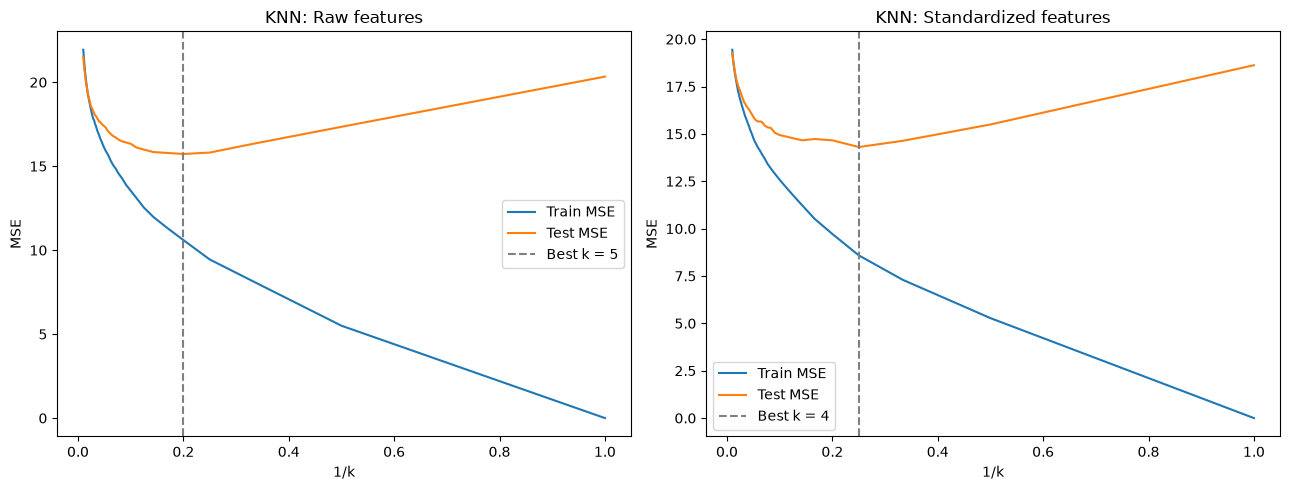

,Best k,Train MSE,Test MSE
Features,,,
Raw,5,10.6008,15.7268
Standardized,4,8.5914,14.3057


In [ ]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

datasets = {
    "Raw": (
        X_train.to_numpy(),
        X_test.to_numpy()
    ),
    "Standardized": (
        X_train_scaled,
        X_test_scaled
    )
}

knn_curves = {}
best_rows = []

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, (train_X, test_X)) in zip(
    axes, datasets.items()
):
    rows = []

    for k in range(1, 101):
        model = KNeighborsRegressor(
            n_neighbors=k,
            weights="uniform",
            metric="euclidean"
        )
        model.fit(train_X, y_train)

        train_pred = model.predict(train_X)
        test_pred = model.predict(test_X)

        rows.append({
            "k": k,
            "Train MSE": mean_squared_error(
                y_train, train_pred
            ),
            "Test MSE": mean_squared_error(
                y_test, test_pred
            )
        })

    curve = pd.DataFrame(rows).set_index("k")
    knn_curves[name] = curve

    best_k = int(curve["Test MSE"].idxmin())

    best_rows.append({
        "Features": name,
        "Best k": best_k,
        "Train MSE": curve.loc[best_k, "Train MSE"],
        "Test MSE": curve.loc[best_k, "Test MSE"]
    })

    plot_data = curve.copy()
    plot_data["1/k"] = 1 / plot_data.index.to_numpy()
    plot_data = plot_data.sort_values("1/k")

    ax.plot(
        plot_data["1/k"], plot_data["Train MSE"],
        label="Train MSE"
    )
    ax.plot(
        plot_data["1/k"], plot_data["Test MSE"],
        label="Test MSE"
    )

    ax.axvline(
        1 / best_k,
        color="gray",
        linestyle="--",
        label=f"Best k = {best_k}"
    )

    ax.set_xlabel("1/k")
    ax.set_ylabel("MSE")
    ax.set_title(f"KNN: {name} features")
    ax.legend()

plt.tight_layout()
plt.show()

knn_results = pd.DataFrame(best_rows).set_index("Features")
display(knn_results.round(4))

## j

In [49]:
comparison = regression_results.copy()

for name in knn_results.index:
    k = int(knn_results.loc[name, "Best k"])

    comparison.loc[f"KNN {name}, k={k}"] = [
        knn_results.loc[name, "Train MSE"],
        knn_results.loc[name, "Test MSE"]
    ]

display(comparison.sort_values("Test MSE").round(4))

,Train MSE,Test MSE
"KNN Standardized, k=4",8.5914,14.3057
"KNN Raw, k=5",10.6008,15.7268
Full quadratic,17.8878,18.6473
Selected quadratic,17.8908,18.6600
Linear,20.5808,21.2399


## ISLR: 2. 4. 1
A flexible statistical learning method can capture more complex relationships but is also more prone to overfitting. (a) It would generally perform better when the sample size is extremely large and the number of predictors is small, because sufficient data allow complex relationships to be estimated reliably. (b) It would generally perform worse when there are many predictors but few observations, because the risk of overfitting is high. (c) It would generally perform better when the true relationship is highly nonlinear, because it can capture patterns that an inflexible method may miss. (d) It would generally perform worse when the error variance is extremely high, because it is more likely to fit random noise rather than the underlying relationship.

## ISLR: 2. 4. 7
(a) The Euclidean distances from observations 1–6 to the origin are 3, 2, sqrt(10), sqrt(5), sqrt(2), sqrt(3) respectively. (b) With K = 1, the prediction is Green, because the nearest observation is observation 5, which is Green. (c) With K = 3, the nearest observations are 5, 6, and 2, whose labels are Green, Red, and Red, so the majority vote predicts Red. (d) If the Bayes decision boundary is highly nonlinear, we would generally expect a small K to perform best, because it produces a more flexible decision boundary that can capture local patterns, whereas a large K may smooth over these patterns and underfit.